In [6]:
from pathlib import Path
import pygimli as pg  # Stelle sicher, dass das Modul pg importiert ist und verfügbar ist
from pygimli.physics import ert
import matplotlib.pyplot as plt
from datetime import datetime
import os
import numpy as np

from Hilfsfunktionen import T_corr_nach_Inversion
from Hilfsfunktionen import plotting_function

# Read data
file = "two_timesteps_240710_240808.ohm"
two_timesteps = True
base_dir = Path("filtered_data")
data = []
for unterordner in base_dir.iterdir():
    if unterordner.is_dir():
        datei_pfad = unterordner / "two_timesteps_240710_240808.ohm" 
        if datei_pfad.exists():
            daten_objekt = pg.load(str(datei_pfad))
            data.append([unterordner.name, daten_objekt])
            print(f"Load data: {datei_pfad}")

# Create method manager
manager = []
for ts in data:
    manager.append(ert.ERTManager(ts[1], verbose=True))

# Inversion without temperature correction
results_tl_light = [] # list of inversion results
chi2_oT = []
chi2_wT = []
chi2 = []
lam = 79
for mgr,mgr_number in zip(manager, range(len(manager))):
    if mgr_number > 0:
        results_tl_light.append(mgr.invert(mgr.data, quality=34,paraMaxCellSize=0.5,
                    paraDepth=15,lam=lam, dPhi= 0.1, startModel=results_tl_light[mgr_number-1], isReference = True, stopAtChi1=False))
        chi2.append(round(mgr.inv.chi2(),2))
    else:
        results_tl_light.append(mgr.invert(mgr.data, quality=34,paraMaxCellSize=0.5, 
                                     dPhi= 0.1, paraDepth=15,lam=12,stopAtChi1=False)) 
        chi2.append(round(mgr.inv.chi2(),2))
    chi2_oT.append(chi2)
    
# Temperature correction
ort_2 = 'Georg-Westermann-Park'
results_tl_light_corr = [] 
temp_spread = []
timestep = 0
mesh2 = manager[0].mesh.createSubMesh(manager[0].mesh.cells(manager[0].mesh.cellMarkers() == 2))
for count, m in enumerate(results_tl_light):
    if two_timesteps:
        add = 10
    else:
        add = 0
    timestep = count+add
    dateien = os.listdir(r".\Temperature_data/" + ort_2 )
    for datei in dateien: 
        if (datei).startswith('T_Profil%s_array' % (str(timestep))):
            print(datei)
            Temp_tiefe_vektor = np.load(r'.\Temperature_data/%s/' % (ort_2) + datei, allow_pickle=True)
    res_new,Tem_new = T_corr_nach_Inversion(m, mesh2, Temp_tiefe_vektor)
    results_tl_light_corr.append(res_new) 
    temp_spread.append(Tem_new)

for resu, resu_corr, man, wen in zip(results_tl_light,results_tl_light_corr,manager, data):
    response = man.inv.fop.response(resu)
    response_t_corr = man.inv.fop.response(resu_corr)
    difference = response_t_corr - response
    wen[1]['rhoa'] = wen[1]['rhoa'] + difference
for dat in data:
    dat[1].remove(dat[1]['rhoa']<0)
# Inversion with temperature correction
results_tl_light_Tcorr = []
chi2 = []
lam = 79
for mgr,mgr_number in zip(manager, range(len(manager))):
    if mgr_number > 0:
        results_tl_light_Tcorr.append(mgr.invert(mgr.data, quality=34,paraMaxCellSize=0.5,
                    paraDepth=15,lam=lam, dPhi= 0.1, startModel=results_tl_light_Tcorr[mgr_number-1], isReference = True,stopAtChi1=False))
        chi2.append(round(mgr.inv.chi2(),2))
    else:
        results_tl_light_Tcorr.append(mgr.invert(mgr.data, quality=34,paraMaxCellSize=0.5, 
                                     dPhi= 0.1, paraDepth=15,lam=12,stopAtChi1=False)) 
        chi2.append(round(mgr.inv.chi2(),2))
    chi2_wT.append(chi2)


Load data: filtered_data\240710\two_timesteps_240710_240808.ohm
Load data: filtered_data\240808\two_timesteps_240710_240808.ohm


31/08/25 - 15:16:21 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 15:16:21 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 15:16:21 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 15:16:21 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 15:16:21 - pyGIMLi - INFO - Creating forward mesh from region infos.
31/08/25 - 15:16:21 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
31/08/25 - 15:16:22 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
31/08/25 - 15:16:22 - pyGIMLi - INFO - Use median(data values)=2117.76
31/08/25 - 15:16:22 - pyGIMLi - INFO - Created startmodel from forward operator: 3104, min/max=2117.760000/2117.760000
31/08/25 - 15:16:22 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000028450C08130>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x0000028450C43880>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000028450C43E70>
min/max (data): 77.42/6811
min/max (error): 4.3%/4.31%
min/max (start model): 2118/2118
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  500.83
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   10.59 (dPhi = 96.96%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    8.40 (dPhi = 20.02%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    6.79 (dPhi = 18.07%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    5.49 (dPhi = 17.54%) lam: 12.0
----------

31/08/25 - 15:21:50 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 15:21:50 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 15:21:50 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 15:21:50 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 15:21:50 - pyGIMLi - INFO - Creating forward mesh from region infos.


chi² =    0.89 (dPhi = 0.01%) lam: 12.0
################################################################################
#                Abort criterion reached: dPhi = 0.01 (< 0.1%)                 #
################################################################################


...

fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000028450C42930>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x0000028450C723E0>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000028450DCF7E0>
min/max (data): 75.9/5324
min/max (error): 3.14%/3.15%
min/max (start model): 18.39/8715
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =   35.73
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    1.50 (dPhi = 93.91%) lam: 79.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    1.28 (dPhi = 10.57%) lam: 79.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.27 (dPhi = 0.08%) lam: 79.0
################################################################################
#                Abort criterion reached: dPhi = 0.08 (< 0.1%)    

31/08/25 - 15:23:42 - pyGIMLi - INFO - Use median(data values)=1590.5185843020581
31/08/25 - 15:23:42 - pyGIMLi - INFO - Created startmodel from forward operator: 3104, min/max=1590.518584/1590.518584
31/08/25 - 15:23:42 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000028450C08130>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x0000028450C43880>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000028450C43E70>
min/max (data): 48.93/5518
min/max (error): 4.3%/4.31%
min/max (start model): 1591/1591
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  556.16
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   12.24 (dPhi = 96.89%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    9.78 (dPhi = 19.57%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    7.82 (dPhi = 19.06%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    6.40 (dPhi = 16.81%) lam: 12.0
----------

31/08/25 - 15:28:10 - pyGIMLi - INFO - Starting inversion.
31/08/25 - 15:28:10 - pyGIMLi - INFO - Setting starting model as reference!


chi² =    1.37 (dPhi = 0.04%) lam: 12.0
################################################################################
#                Abort criterion reached: dPhi = 0.04 (< 0.1%)                 #
################################################################################
fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000028450C42930>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x0000028450C723E0>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000028450DCF7E0>
min/max (data): 46.75/4393
min/max (error): 3.14%/3.15%
min/max (start model): 10.14/6994
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =   32.34
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    2.19 (dPhi = 90.72%) lam: 79.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    1.98 (dPhi = 8.46%) lam: 79.0


In [5]:
data

[['240710',
  Data: Sensors: 50 data: 802, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']],
 ['240808',
  Data: Sensors: 50 data: 802, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']]]

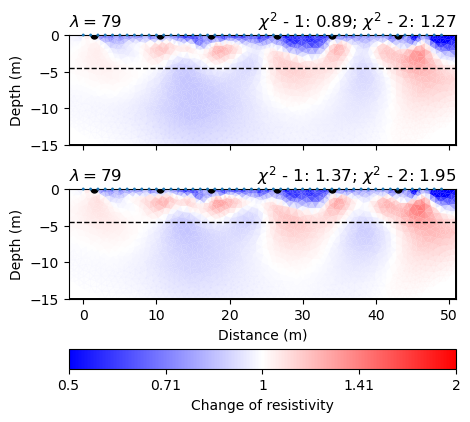

In [11]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5,6))
axs = axs.flatten()
plt.subplots_adjust(hspace=-0.5)
for nr, chi2, m, name in zip([0,1],[chi2_oT, chi2_wT], [results_tl_light, results_tl_light_Tcorr], ['withoutTcorr', 'withTcorr']):
    ratio = m[1] / m[0]
    bild2 = manager[0].showResult(model= ratio,coverage = manager[0].coverage(),
            cMin=1/2, cMax=2, cMap= 'bwr', ax= axs[nr], label = 'Change of resistivity', logScale= True)
    if nr < 1:
        cb = bild2[-1]
        cb.remove() 
        axs[nr].xaxis.set_ticklabels([])  # Unterdrückt die x-Achse Labels
    if nr == 1:
        axs[nr].set_xlabel('Distance (m)')
    axs[nr].set_ylabel('Depth (m)')    
    axs[nr].set_title('$\chi^2$ - 1: '+ str(chi2[0][0]) + '; $\chi^2$ - 2: ' + str(chi2[0][1]), loc = 'right')
    axs[nr].set_title('$\lambda = $'+ str(79), loc = 'left')
    # Prinzenpark
    axs[nr].plot(1.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(10.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(17.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(26.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(34,0, '.', markersize = '10 ', color = 'black')
    axs[nr].plot(43,0, '.', markersize = '10 ', color = 'black')
    axs[nr].set_ylim(-15, 0)
    axs[nr].axhline(y=-4.5, color='k', linewidth = 1,linestyle='--')

fig.savefig('./Fig8/Ref_inversion_new.png', bbox_inches = 'tight', dpi=300)